In [69]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

df = pd.read_csv('240710_uniprot_membrane_proteins+capillary_expression_v4.csv')
df



,Entry,gene,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Names (synonym),Transmembrane,...,bjornholm_Pericyte,bjornholm_Erythrocyte,bjornholm_ArtEC,bjornholm_VenEC,bjornholm_Myeloid,bjornholm_Astrocyte,bjornholm_B-lymphocyte,bjornholm_ChP epithelial,bjornholm_T-lymphocyte,bjornholm_Fibroblast
0,A0A087WPF7,Auts2,reviewed,AUTS2_MOUSE,Autism susceptibility gene 2 protein homolog,Auts2 Kiaa0442,Mus musculus (Mouse),1261,Kiaa0442,NaN,...,0.097686,0.137003,0.390969,0.907178,0.025558,0.190598,0.010238,0.100040,0.070561,0.624372
1,A0A088MLT8,Schip1,reviewed,IQIP1_MOUSE,IQCJ-SCHIP1 readthrough transcript protein,Iqcj-Schip1 Iqschfp Schip1,Mus musculus (Mouse),559,Iqschfp Schip1,NaN,...,0.131164,0.049715,0.137279,0.081022,0.000000,0.060567,0.000000,0.049424,0.004872,0.000000
2,A0A0A6YXX9,Gm16432,reviewed,CTSEL_MOUSE,Cation channel sperm-associated protein subuni...,Catspere2 Gm16432,Mus musculus (Mouse),775,Gm16432,NaN,...,0.000000,0.002838,0.001947,0.004609,0.000000,0.000000,0.000000,0.037353,0.000000,0.000000
3,A0A0A6YY25,Btbd18,reviewed,BTBDI_MOUSE,BTB/POZ domain-containing protein 18,Btbd18,Mus musculus (Mouse),723,NaN,NaN,...,0.002253,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,A0A0B4J1F4,Arrdc4,reviewed,ARRD4_MOUSE,Arrestin domain-containing protein 4,Arrdc4,Mus musculus (Mouse),415,NaN,NaN,...,0.016081,0.006091,0.008779,0.028367,0.099269,0.008379,0.000000,0.015422,0.014028,0.188282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16212,S4R2P9,Slc8a3,reviewed,NAC3_MOUSE,Sodium/calcium exchanger 3 (Na(+)/Ca(2+)-excha...,Slc8a3 Ncx3,Mus musculus (Mouse),928,Ncx3,"TRANSMEM 74..94; /note=""Helical""; /evidence=""E...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16213,T1NXB5,Vstm4,reviewed,VSTM4_MOUSE,V-set and transmembrane domain-containing prot...,Vstm4,Mus musculus (Mouse),319,NaN,"TRANSMEM 180..200; /note=""Helical""; /evidence=...",...,0.490153,0.010374,0.000000,0.010124,0.002851,0.014766,0.000000,0.000000,0.015897,1.119565
16214,V9GXG1,Slfn14,reviewed,SLN14_MOUSE,Protein SLFN14 [Cleaved into: C-terminally tru...,Slfn14,Mus musculus (Mouse),899,NaN,NaN,...,0.000000,0.004639,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
16215,V9GXK1,Ccpg1os,reviewed,PIRC2_MOUSE,Piercer of microtubule wall 2 protein,PIERCE2 Ccpg1os,Mus musculus (Mouse),122,Ccpg1os,NaN,...,0.053038,0.025181,0.019770,0.031635,0.009673,0.039998,0.003485,0.097336,0.012038,0.027776


Make a plot for each gene, expression level in cell types not endothelial, brain only

- Subset only columns we need
- Choose an example gene, generate plot just for that gene
- Write a loop to generate plots for all genes
- Upload the new images to Google Cloud
- Edit the website code to incorporate the new images
- Push all to GitHub

In [4]:
# see all columns
df.columns.values

array(['Entry', 'gene', 'Reviewed', 'Entry Name', 'Protein names',
       'Gene Names', 'Organism', 'Length', 'Gene Names (synonym)',
       'Transmembrane', 'Subcellular location [CC]', 'has_tm_annotation',
       'cell_membrane_localization', 'cap_expression',
       'cap_expression_above_threshold', 'jeong_Venous', 'jeong_CapA',
       'jeong_CapV', 'jeong_REV', 'jeong_Arterial',
       'kalucka_brain-capillary venous',
       'kalucka_brain-artery shear stress', 'kalucka_brain-interferon',
       'kalucka_brain-capillary', 'kalucka_brain-artery',
       'kalucka_brain-capillary arterial', 'kalucka_brain-large artery',
       'kalucka_brain-choroid plexus', 'kalucka_brain-large vein',
       'kalucka_heart-capillary', 'kalucka_heart-large vein',
       'kalucka_heart-capillary arterial', 'kalucka_heart-angiogenic',
       'kalucka_heart-capillary venous', 'kalucka_heart-artery',
       'kalucka_heart-interferon', 'kalucka_heart-lymphatic',
       'kalucka_intestine_colon-capillary 2

In [ ]:
# select subset
subset_columns = [
    'gene',

    'bets_brain_MG', # microglia 
    'bjornholm_Microglia',

    'bets_brain_PC', #pericyte
    'bjornholm_Pericyte',

    'bets_brain_vSMC', # venous smooth muscle cells
    'bjornholm_VSMC',

    'bets_brain_aSMC', #arterial

    'bets_brain_aaSMC', # arteriolar smooth muscle cells

    'bets_brain_AC', #astrocytes
    'bjornholm_Astrocyte',
    
    'bets_brain_OL', #oligodendrocytes
    
    'bets_brain_FB1', #fibroblasts
    'bets_brain_FB2',
    'bjornholm_Fibroblast',

    'bjornholm_Erythrocyte',
    'bjornholm_B-lymphocyte',
    'bjornholm_T-lymphocyte'
    
]

dff = df[subset_columns]
dff

,gene,bets_brain_MG,bjornholm_Microglia,bets_brain_PC,bjornholm_Pericyte,bets_brain_vSMC,bjornholm_VSMC,bets_brain_aSMC,bets_brain_aaSMC,bets_brain_AC,bjornholm_Astrocyte,bets_brain_OL,bets_brain_FB1,bets_brain_FB2,bjornholm_Fibroblast,bjornholm_Erythrocyte,bjornholm_B-lymphocyte,bjornholm_T-lymphocyte
0,Auts2,0.000714,0.007378,0.006471,0.097686,0.003411,0.196676,0.009308,0.000000,0.092222,0.190598,0.025742,0.144730,0.020510,0.624372,0.137003,0.010238,0.070561
1,Schip1,NaN,0.002024,NaN,0.131164,NaN,0.123534,NaN,NaN,NaN,0.060567,NaN,NaN,NaN,0.000000,0.049715,0.000000,0.004872
2,Gm16432,0.000000,0.007344,0.000515,0.000000,0.000000,0.000000,0.000000,0.000250,0.000000,0.000000,0.000516,0.003108,0.000000,0.000000,0.002838,0.000000,0.000000
3,Btbd18,0.000000,0.000000,0.000864,0.002253,0.007523,0.000000,0.004154,0.000000,0.000000,0.000000,0.000000,0.021216,0.000306,0.000000,0.000000,0.000000,0.000000
4,Arrdc4,0.080714,0.051965,0.004122,0.016081,0.000000,0.016716,0.034192,0.144083,0.000000,0.008379,0.016839,0.136216,0.130204,0.188282,0.006091,0.000000,0.014028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16212,Slc8a3,0.009643,NaN,0.003359,NaN,0.000000,NaN,0.000000,0.000167,0.000000,NaN,0.055968,0.020946,0.022857,NaN,NaN,NaN,NaN
16213,Vstm4,0.060000,0.002979,1.234600,0.490153,0.727290,0.132854,0.305654,0.679583,1.975556,0.014766,0.006323,0.412297,1.523367,1.119565,0.010374,0.000000,0.015897
16214,Slfn14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000848,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004639,0.000000,0.000000
16215,Ccpg1os,0.000000,0.013618,0.025124,0.053038,0.023224,0.047767,0.010731,0.005333,0.062222,0.039998,0.015226,0.010405,0.028980,0.027776,0.025181,0.003485,0.012038


In [ ]:
dff['gene'] == 'Tjp1'
#specify rows then columns




0        False
1        False
2        False
3        False
4        False
         ...  
16212    False
16213    False
16214    False
16215    False
16216    False
Name: gene, Length: 16217, dtype: bool

In [ ]:
dff.loc[dff['gene'] == 'Tjp1']

,gene,bets_brain_MG,bjornholm_Microglia,bets_brain_PC,bjornholm_Pericyte,bets_brain_vSMC,bjornholm_VSMC,bets_brain_aSMC,bets_brain_aaSMC,bets_brain_AC,bjornholm_Astrocyte,bets_brain_OL,bets_brain_FB1,bets_brain_FB2,bjornholm_Fibroblast,bjornholm_Erythrocyte,bjornholm_B-lymphocyte,bjornholm_T-lymphocyte
2955,Tjp1,0.190357,0.489701,0.823134,1.159536,0.547477,0.699547,0.160308,0.482583,0.4275,1.086967,0.230065,0.530946,0.281939,0.503651,1.128432,0.290408,0.173677


In [16]:
expression_lvls = (
    dff # subsetted df
    .loc[dff['gene'] == 'Tjp1'] #selecting all col from ZO-1
    .iloc[:, 1:] # all columns except the first
    .values # convert from table to vector
    )[0] # flattening from 2d to 1d array 
expression_lvls

array([0.19035714, 0.48970124, 0.82313419, 1.15953579, 0.54747664,
       0.69954662, 0.16030769, 0.48258333, 0.4275    , 1.08696718,
       0.23006452, 0.53094595, 0.28193878, 0.5036515 , 1.12843243,
       0.29040845, 0.17367703])

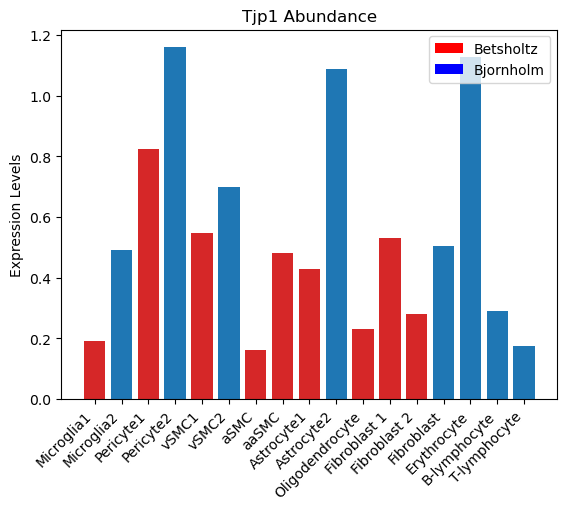

In [ ]:
# data from https://allisonhorst.github.io/palmerpenguins/

gene_name = 'Tjp1'

fig, ax = plt.subplots()

y = expression_lvls

x = ['Microglia1', 'Microglia2', 'Pericyte1', 'Pericyte2', 'vSMC1', 'vSMC2', 'aSMC', 'aaSMC', 'Astrocyte1', 'Astrocyte2', 'Oligodendrocyte', 'Fibroblast 1', 'Fibroblast 2', 'Fibroblast', 'Erythrocyte', 'B-lymphocyte', 'T-lymphocyte']

bar_labels = range(17)
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:red', 'tab:red', 'tab:blue', 'tab:red', 'tab:red', 'tab:red', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:blue'] 

ax.bar(x, y, label=bar_labels, color=bar_colors)

ax.set_ylabel('Expression Levels')
ax.set_title(gene_name + ' Abundance')
ax.legend(title='Source')
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [
                    Patch(facecolor='red',
                         label='Betsholtz'),
                    Patch(facecolor='blue',
                         label='Bjornholm')]


ax.legend(handles=legend_elements, loc='upper right')
plt.xticks(rotation=45, ha="right")

fig.savefig("test.svg", bbox_inches='tight')
plt.show()


[0.00107143 0.05974938 0.0261443 ] nan 0.2000437537009404 nan [7.11666667e-02 6.63888889e-02 4.94801607e-01 1.17096774e-02
 9.33783784e-02 1.02040816e-04 3.45945242e-02 6.19883504e-01
 1.39326668e-01 8.13392917e-02]
<class 'numpy.ndarray'>


/Users/rutinghung/anaconda3/lib/python3.10/site-packages/numpy/lib/stride_tricks.py:538: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  args = [np.array(_m, copy=False, subok=subok) for _m in args]


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (7,) and arg 1 with shape (2,).

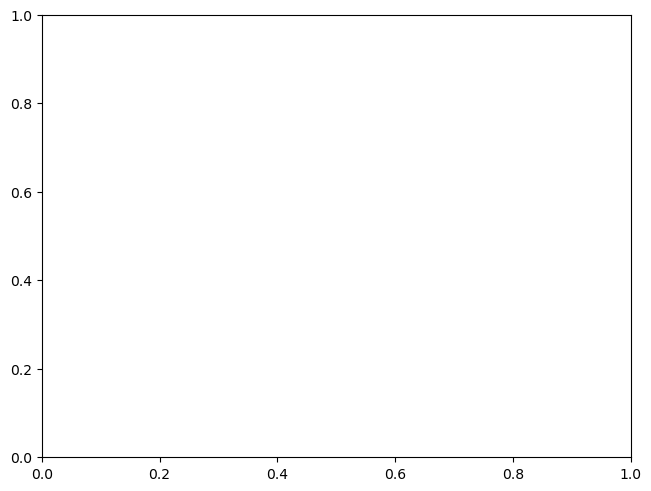

In [ ]:

    
    

# Grouped by cell type

# species = ("Adelie", "Chinstrap", "Gentoo")
cell_types = ['Microglia', 'Pericyte', 'Venous', 'Arterial', 'Arteriolar', 'Astrocyte', 'Oligodendrocyte', 'Fibroblast', 'Erythrocyte', 'B-lymphocyte', 'T-lymphocyte']

'''
penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}
'''

exp = {
    "Betsholtz" : {
        "Microglia" : 'bets_brain_MG',
        "Pericyte" : 'bets_brain_PC',
        "Venous" : 'bets_brain_vSMC',
        "Arterial" : 'bets_brain_aSMC',
        "Arteriolar" : 'bets_brain_aaSMC',
        "Astrocytes" : 'bets_brain_AC',
        "Oligodendrocytes" : 'bets_brain_OL',
        "Fibroblasts" : 'bets_brain_FB1', 'bets_brain_FB2'
    }

    "Bjornholm" : {
        "Microglia": 'bjornholm_Microgila',
        "Pericyte" : 'bjornholm_Pericyte',
        "Venous smooth muscle" : 'bjornholm_VSMC',
        "Astrocytes" : 'bjornholm_Astrocyte',
        "Fibroblasts" : 'bjornholm_Fibroblast',
        "Erythrocytes" : 'bjornholm_Erythrocyte',
        "B-lymphocytes" : 'bjornholm_B-lymphocyte',
        "T-lymphocytes" : 'bjornholm_T-lymphocyte'
    
    }
    }
print(exp)

# x = np.arange(len(species))  # the label locations
X = np.arange(len(cell_types))
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in exp.items():
    offset = width * multiplier
    rects = ax.bar(X + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Expression')
ax.set_title('RNA expression in non-endothelial cell types')
ax.set_xticks(x + width, cell_types)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 250)

plt.show()


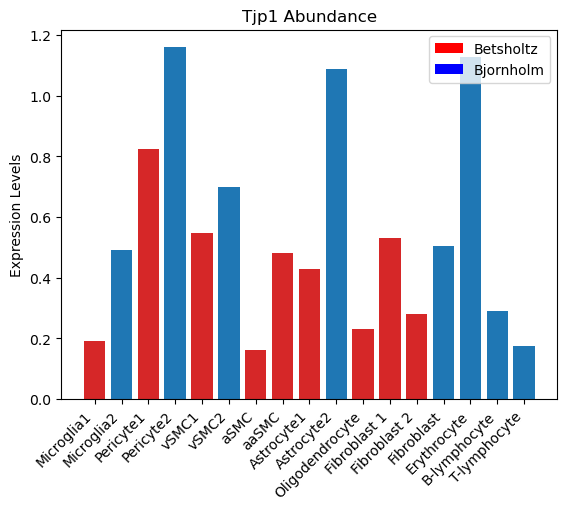

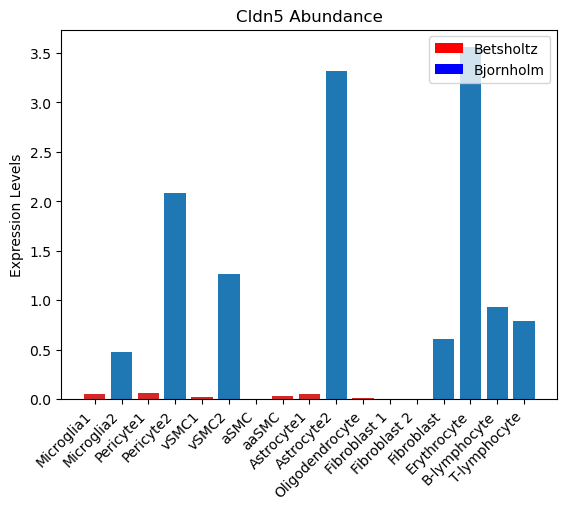

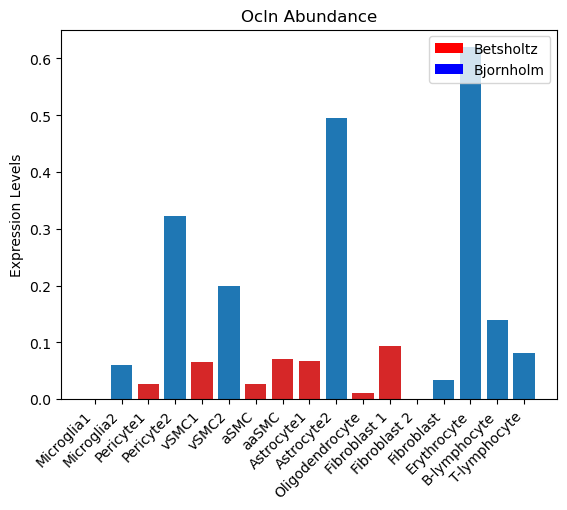

In [79]:
for gene in ['Tjp1', 'Cldn5', 'Ocln']:
    expression_lvls = (
    dff # subsetted df
    .loc[dff['gene'] == gene] #selecting all col from ZO-1
    .iloc[:, 1:] # all columns except the first
    .values # convert from table to vector
    )[0] # flattening from 2d to 1d array 

    fig, ax = plt.subplots()

    y = expression_lvls

    x = ['Microglia1', 'Microglia2', 'Pericyte1', 'Pericyte2', 'vSMC1', 'vSMC2', 'aSMC', 'aaSMC', 'Astrocyte1', 'Astrocyte2', 'Oligodendrocyte', 'Fibroblast 1', 'Fibroblast 2', 'Fibroblast', 'Erythrocyte', 'B-lymphocyte', 'T-lymphocyte']

    bar_labels = range(17)
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:blue', 'tab:red', 'tab:red', 'tab:red', 'tab:blue', 'tab:red', 'tab:red', 'tab:red', 'tab:blue', 'tab:blue', 'tab:blue', 'tab:blue'] 

    ax.bar(x, y, label=bar_labels, color=bar_colors)

    ax.set_ylabel('Expression Levels')
    ax.set_title(gene + ' Abundance')
    ax.legend(title='Source')
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_elements = [
                        Patch(facecolor='red',
                            label='Betsholtz'),
                        Patch(facecolor='blue',
                            label='Bjornholm')]


    ax.legend(handles=legend_elements, loc='upper right')
    plt.xticks(rotation=45, ha="right")

    fig.savefig(f"{gene}.svg", bbox_inches='tight')
    plt.show()
